# Activity 1: Cluster Statistics & Demographic Analysis

In [1]:
import pandas as pd
import numpy as np


In [2]:
import pandas as pd

df_clustered = pd.read_csv("Customer_Segmentation_Final.csv")

df_clustered.head()

,Education,Marital_Status,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Total_Purchase,Total_Campaign,Average Spending per Purchase,Digital_Engagement,Deal_Dependency,Preferred_Shopping_Channel,Product_Preference,Customer_Activity_Level,Cluster,Customer_Segment
0,-0.458383,1.251776,0.299651,0.307039,0.989643,1.470132,1.442724,1.434322,1.455038,1.121518,...,1.380023,0.0,1.176601,1.620481,-0.514589,-2.187642,0.512133,1.276773,0,High-Value Customers
1,-0.458383,1.251776,-0.263808,-0.383664,-1.213866,-1.000697,-1.415023,-0.874095,-0.986677,-0.921817,...,-1.163336,0.0,-1.629866,-0.965311,1.417872,-0.361890,0.512133,-1.211241,1,Premium Buyers
2,-0.458383,-0.272125,0.943420,-0.798086,0.768523,1.140985,0.490422,1.383545,0.589966,0.536950,...,0.844579,0.0,0.592428,0.758551,-1.255068,-0.361890,0.512133,1.276773,0,High-Value Customers
3,-0.458383,-0.272125,-1.204881,-0.798086,-1.213866,-0.391042,-0.694700,-0.063762,-0.530925,-1.045693,...,-0.895614,0.0,-1.254015,-0.390691,0.702554,-0.361890,-0.653942,-1.211241,1,Premium Buyers
4,1.533425,-0.272125,0.307056,1.550305,0.270284,1.055931,0.442620,0.841975,0.748533,-0.257498,...,0.576857,0.0,0.026695,0.183930,0.818614,-0.361890,0.512133,0.032766,0,High-Value Customers


In [3]:
df_clustered.columns

Index(['Education', 'Marital_Status', 'Income', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Year', 'Month', 'Day',
       'Customer_Age', 'Customer_Tenure', 'Total_Children', 'Partner',
       'Family_size', 'Total_spending', 'Total_Purchase', 'Total_Campaign',
       'Average Spending per Purchase', 'Digital_Engagement',
       'Deal_Dependency', 'Preferred_Shopping_Channel', 'Product_Preference',
       'Customer_Activity_Level', 'Cluster', 'Customer_Segment'],
      dtype='str')

### Calculate the average value of each feature by cluster.

In [4]:
numeric_cols = df_clustered.select_dtypes(include=['number']).columns
avg_features = df_clustered.groupby('Cluster')[numeric_cols].mean()
print("--- Average Values per Cluster ---")
print(avg_features)

--- Average Values per Cluster ---
         Education  Marital_Status    Income   Recency  MntWines  MntFruits  \
Cluster                                                                       
0         0.088423        0.014549  0.672480  0.013755  0.759971   0.577810   
1        -0.109225       -0.010744 -0.797815 -0.015736 -0.913876  -0.685037   

         MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  \
Cluster                                                                     
0               0.758317         0.571659          0.553149      0.560285   
1              -0.908298        -0.698118         -0.661865     -0.684287   

         ...  Total_spending  Total_Purchase  Total_Campaign  \
Cluster  ...                                                   
0        ...        0.805177        0.760238             0.0   
1        ...       -0.967041       -0.914675             0.0   

         Average Spending per Purchase  Digital_Engagement  Deal_Dependency  \
Clu

### Check Cluster Distribution and Compare customer age across clusters.

In [5]:
cluster_count=df_clustered['Cluster'].value_counts().sort_index()
print("\n--- Customer Count per Cluster ---")
print(cluster_count)

age_comparison = df_clustered.groupby('Cluster')['Customer_Age'].mean()
print("\n--- Average Age per Cluster ---")
print(age_comparison)


--- Customer Count per Cluster ---
Cluster
0    1111
1     927
Name: count, dtype: int64

--- Average Age per Cluster ---
Cluster
0    0.175124
1   -0.203299
Name: Customer_Age, dtype: float64


### Compare income and  Compare education levels across clusters.

In [6]:
print("Income across Cluster")
income_comp=df_clustered.groupby("Cluster")["Income"].mean()
print(income_comp)
print("Education across Cluster")
edu_comp=df_clustered.groupby("Cluster")['Education'].mean()
print(edu_comp)

Income across Cluster
Cluster
0    0.672480
1   -0.797815
Name: Income, dtype: float64
Education across Cluster
Cluster
0    0.088423
1   -0.109225
Name: Education, dtype: float64


### Compare marital status ,Compare Family_Size and Compare the number of children.


In [7]:
print("Martial Status across Cluster")
martial_comp=df_clustered.groupby("Cluster")['Marital_Status'].mean()
print(martial_comp)

print("Family Size across Cluster")
family_comp=df_clustered.groupby("Cluster")['Family_size'].mean()
print(family_comp)

print("Total Children across Cluster")
child_comp=df_clustered.groupby("Cluster")['Total_Children'].mean()
print(child_comp)

Martial Status across Cluster
Cluster
0    0.014549
1   -0.010744
Name: Marital_Status, dtype: float64
Family Size across Cluster
Cluster
0   -0.322754
1    0.381116
Name: Family_size, dtype: float64
Total Children across Cluster
Cluster
0   -0.373558
1    0.453432
Name: Total_Children, dtype: float64


### Create a demographic comparison table.

In [8]:
demp_comp_tabel=df_clustered.groupby("Cluster").agg({
    "Customer_Age":'mean',
    "Income": 'mean',
    "Family_size": 'mean',
    "Total_Children":'mean',
    "Education":'mean',
    "Marital_Status":'mean'
}).reset_index()

print(demp_comp_tabel)

   Cluster  Customer_Age    Income  Family_size  Total_Children  Education  \
0        0      0.175124  0.672480    -0.322754       -0.373558   0.088423   
1        1     -0.203299 -0.797815     0.381116        0.453432  -0.109225   

   Marital_Status  
0        0.014549  
1       -0.010744  


# Activity 2: Spending Behavior Analysis

### Total Spending by Cluster

In [9]:
total_spending=df_clustered.groupby("Cluster")['Total_spending'].mean()
print("Average Total Spendig")
print(total_spending)

Average Total Spendig
Cluster
0    0.805177
1   -0.967041
Name: Total_spending, dtype: float64


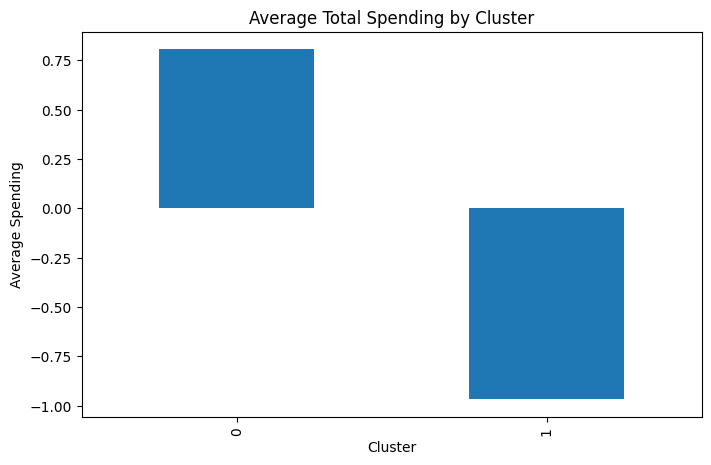

In [10]:
import matplotlib.pyplot as plt

total_spending.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Total Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Spending")

plt.show()

### Product-wise Spending

In [11]:
product_spending = df_clustered.groupby("Cluster")[[
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]].mean().round(2)

product_spending

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,
0,0.76,0.58,0.76,0.57,0.55,0.56
1,-0.91,-0.69,-0.91,-0.70,-0.66,-0.68


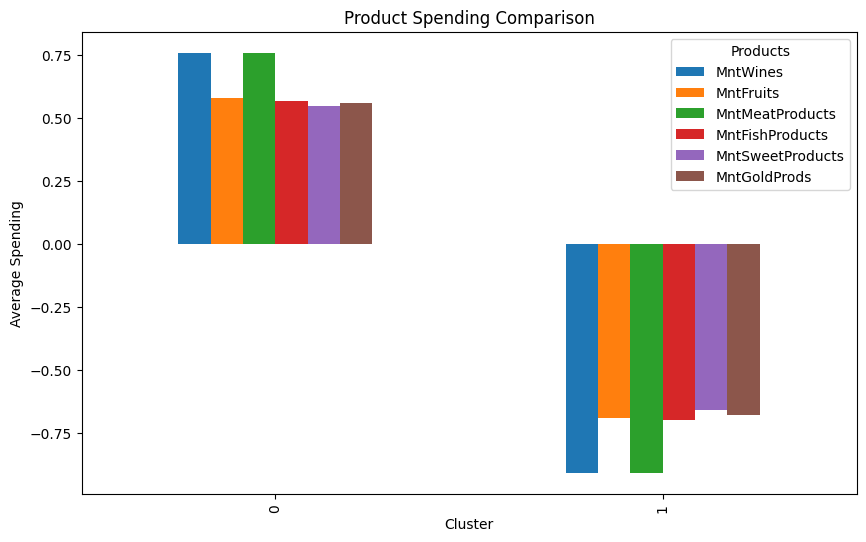

In [12]:
import matplotlib.pyplot as plt
product_spending.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Product Spending Comparison")
plt.xlabel("Cluster")
plt.ylabel("Average Spending")

plt.legend(title="Products")

plt.show()

### Highest Spending Cluster

In [13]:
highest_cluster = total_spending.idxmax()

highest_value = total_spending.max()

print("Highest Spending Cluster :", highest_cluster)

print("Average Spending :", round(highest_value,2))

Highest Spending Cluster : 0
Average Spending : 0.81


### Highest Spending Cluster

In [14]:
lowest_cluster=total_spending.idxmin()

lowest_value=total_spending.min()

print("Highest Cluster :", lowest_cluster)

print("Average Spending :", lowest_value)

Highest Cluster : 1
Average Spending : -0.9670412068232698


### Premium Product Buyers

In [15]:
premium_score = product_spending["MntWines"] + product_spending["MntMeatProducts"]
premium_cluster = premium_score.idxmax()

print("Premium Product Buyers Cluster :", premium_cluster)

Premium Product Buyers Cluster : 0


### Identify budget-conscious customers.

In [16]:
budget_cluster = total_spending.idxmin()

print("Budget-Conscious Customer Cluster :", budget_cluster)

Budget-Conscious Customer Cluster : 1


# Activity 3: Shopping Channel & Customer Engagement Analysis

### Shopping Channel Comparison

In [17]:
channel_analysis = df_clustered.groupby("Cluster")[[
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases"
]].mean().round(2)

channel_analysis

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases
Cluster,,,,
0,0.66,0.73,0.71,0.04
1,-0.78,-0.88,-0.86,-0.04


### Website Visits Analysis

In [18]:
website_visits = df_clustered.groupby("Cluster")["NumWebVisitsMonth"].mean().round(2)

print("Average Website Visits")
print(website_visits)

Average Website Visits
Cluster
0   -0.40
1    0.47
Name: NumWebVisitsMonth, dtype: float64


### Recency Analysis

In [19]:
recency_analysis = df_clustered.groupby("Cluster")["Recency"].mean().round(2)

print("Average Recency")
print(recency_analysis)

Average Recency
Cluster
0    0.01
1   -0.02
Name: Recency, dtype: float64


### Shopping Channel Comparison Chart

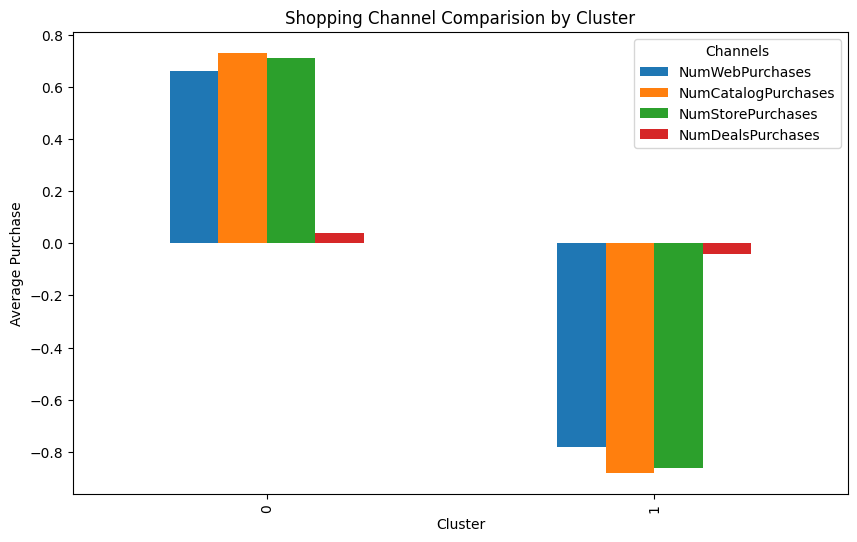

In [20]:
import matplotlib.pyplot as plt

channel_analysis.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Shopping Channel Comparision by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Purchase")

plt.legend(title="Channels")

plt.show()

### Website Visits Chart

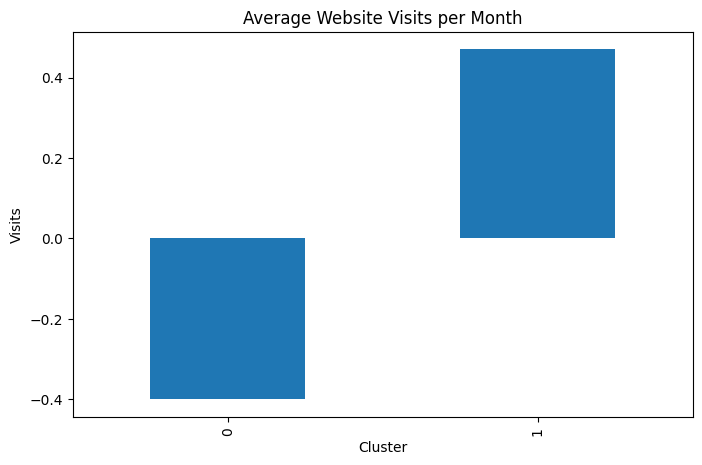

In [21]:
website_visits.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Website Visits per Month")
plt.xlabel("Cluster")
plt.ylabel("Visits")

plt.show()

### Recency Comparison Chart

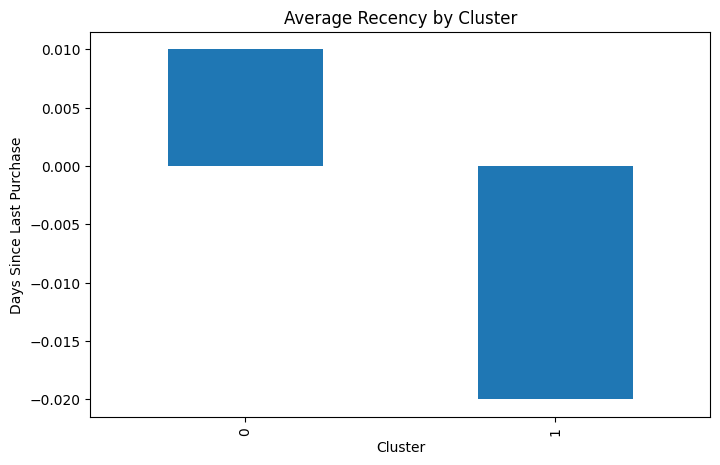

In [22]:
recency_analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Recency by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Days Since Last Purchase")

plt.show()

### Identify Digital-First Customers

In [23]:
digital_cluster = channel_analysis["NumWebPurchases"].idxmax()

print("Digital-First Customer Cluster:", digital_cluster)

Digital-First Customer Cluster: 0


### Identify Store-Oriented Customers

In [24]:
store_cluster = channel_analysis["NumStorePurchases"].idxmax()

print("Store-Oriented Customer Cluster:", store_cluster)

Store-Oriented Customer Cluster: 0


### Identify Catalog-Oriented Customers

In [25]:
catalog_cluster = channel_analysis["NumCatalogPurchases"].idxmax()

print("Catalog-Oriented Customer Cluster:", catalog_cluster)

Catalog-Oriented Customer Cluster: 0


### Identify Deal-Seeking Customers

In [26]:
deal_cluster = channel_analysis["NumDealsPurchases"].idxmax()

print("Deal-Seeking Customer Cluster:", deal_cluster)

Deal-Seeking Customer Cluster: 0


### Active & Inactive Customer Segments

In [27]:
active_cluster = recency_analysis.idxmin()

inactive_cluster = recency_analysis.idxmax()

print("Most Active Cluster:", active_cluster)
print("Least Active Cluster:", inactive_cluster)

Most Active Cluster: 1
Least Active Cluster: 0


### Customer Engagement Summary

In [28]:
engagement_summary = pd.DataFrame({

    "Web Purchases": channel_analysis["NumWebPurchases"],
    "Catalog Purchases": channel_analysis["NumCatalogPurchases"],
    "Store Purchases": channel_analysis["NumStorePurchases"],
    "Deal Purchases": channel_analysis["NumDealsPurchases"],
    "Website Visits": website_visits,
    "Recency": recency_analysis

}).round(2)

engagement_summary

,Web Purchases,Catalog Purchases,Store Purchases,Deal Purchases,Website Visits,Recency
Cluster,,,,,,
0,0.66,0.73,0.71,0.04,-0.40,0.01
1,-0.78,-0.88,-0.86,-0.04,0.47,-0.02


### Activity 4: Marketing Campaign Analysis

### Campaign Acceptance Analysis

In [29]:
campaign_analysis = df_clustered.groupby("Cluster")[[
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]].mean().round(2)

campaign_analysis

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
Cluster,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0


### Complaint Analysis

In [30]:
complaint_analysis = df_clustered.groupby("Cluster")["Complain"].mean().round(2)

print("Complaint Rate by Cluster")
print(complaint_analysis)

Complaint Rate by Cluster
Cluster
0    0.0
1    0.0
Name: Complain, dtype: float64


### Campaign Comparison Chart

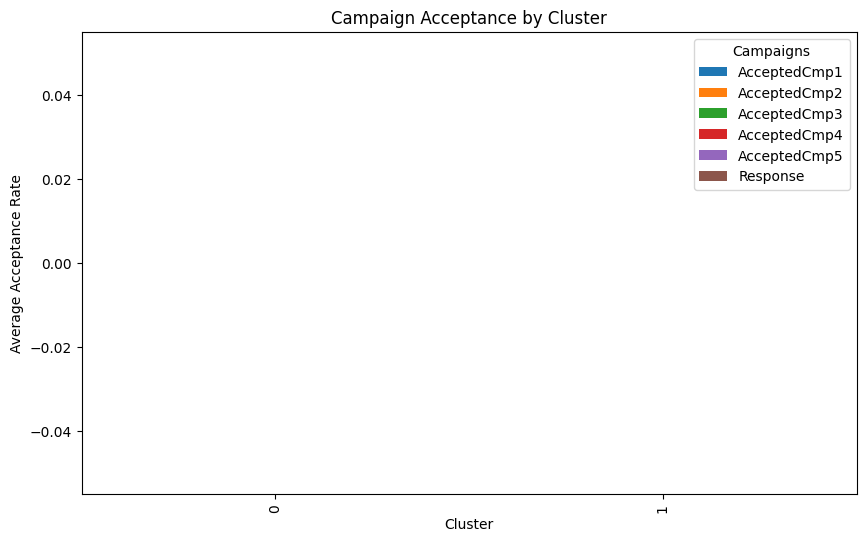

In [31]:
import matplotlib.pyplot as plt

campaign_analysis.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Campaign Acceptance by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Acceptance Rate")

plt.legend(title="Campaigns")

plt.show()

### Complaint Comparison Chart

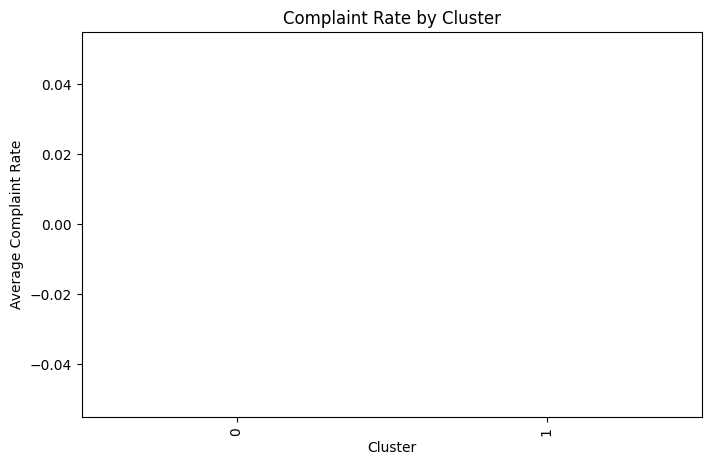

In [32]:
complaint_analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Complaint Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Complaint Rate")

plt.show()

### Overall Campaign Response

In [33]:
campaign_analysis["Overall_Response"] = campaign_analysis.mean(axis=1)

campaign_analysis

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Overall_Response
Cluster,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0


###  Marketing-Resistant Customers and Customers Requiring Re-engagement

In [35]:
resistant_cluster = campaign_analysis["Overall_Response"].idxmin()

print("Marketing-Resistant Customer Cluster:", resistant_cluster)


reengagement = pd.DataFrame({
    "Campaign Response": campaign_analysis["Overall_Response"],
    "Average Recency": df_clustered.groupby("Cluster")["Recency"].mean()
})

reengagement

Marketing-Resistant Customer Cluster: 0


,Campaign Response,Average Recency
Cluster,,
0,0.0,0.013755
1,0.0,-0.015736


### Identify Re-engagement Cluster

In [36]:
reengagement_cluster = reengagement.sort_values(
    by=["Campaign Response", "Average Recency"],
    ascending=[True, False]
).index[0]

print("Customers Requiring Re-engagement:", reengagement_cluster)

Customers Requiring Re-engagement: 0


### Marketing Insights Summary

In [38]:
marketing_summary = pd.DataFrame({

    "Campaign Response": campaign_analysis["Overall_Response"],
    "Complaint Rate": complaint_analysis,
    "Average Recency": df_clustered.groupby("Cluster")["Recency"].mean()

}).round(2)

marketing_summary

,Campaign Response,Complaint Rate,Average Recency
Cluster,,,
0,0.0,0.0,0.01
1,0.0,0.0,-0.02


### Activity 5: Business Segmentation & Cluster Naming

### Cluster Summary

In [40]:
cluster_summary = df_clustered.groupby("Cluster").agg({

    "Income":"mean",
    "Total_spending":"mean",
    "Recency":"mean",
    "NumWebPurchases":"mean",
    "NumStorePurchases":"mean",
    "NumCatalogPurchases":"mean",
    "Total_Children":"mean",
    "Family_size":"mean",
    "Total_Campaign":"mean"

}).round(2)

cluster_summary

,Income,Total_spending,Recency,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,Total_Children,Family_size,Total_Campaign
Cluster,,,,,,,,,
0,0.67,0.81,0.01,0.66,0.71,0.73,-0.37,-0.32,0.0
1,-0.80,-0.97,-0.02,-0.78,-0.86,-0.88,0.45,0.38,0.0


### Assign Business Names

In [41]:
cluster_names = {

    0: "Premium Loyal Customers",

    1: "Digital-First Buyers",

    2: "Discount-Driven Families",

    3: "At-Risk Customers"

}

df_clustered["Customer_Segment"] = df_clustered["Cluster"].map(cluster_names)

df_clustered.head()

,Education,Marital_Status,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Total_Purchase,Total_Campaign,Average Spending per Purchase,Digital_Engagement,Deal_Dependency,Preferred_Shopping_Channel,Product_Preference,Customer_Activity_Level,Cluster,Customer_Segment
0,-0.458383,1.251776,0.299651,0.307039,0.989643,1.470132,1.442724,1.434322,1.455038,1.121518,...,1.380023,0.0,1.176601,1.620481,-0.514589,-2.187642,0.512133,1.276773,0,Premium Loyal Customers
1,-0.458383,1.251776,-0.263808,-0.383664,-1.213866,-1.000697,-1.415023,-0.874095,-0.986677,-0.921817,...,-1.163336,0.0,-1.629866,-0.965311,1.417872,-0.361890,0.512133,-1.211241,1,Digital-First Buyers
2,-0.458383,-0.272125,0.943420,-0.798086,0.768523,1.140985,0.490422,1.383545,0.589966,0.536950,...,0.844579,0.0,0.592428,0.758551,-1.255068,-0.361890,0.512133,1.276773,0,Premium Loyal Customers
3,-0.458383,-0.272125,-1.204881,-0.798086,-1.213866,-0.391042,-0.694700,-0.063762,-0.530925,-1.045693,...,-0.895614,0.0,-1.254015,-0.390691,0.702554,-0.361890,-0.653942,-1.211241,1,Digital-First Buyers
4,1.533425,-0.272125,0.307056,1.550305,0.270284,1.055931,0.442620,0.841975,0.748533,-0.257498,...,0.576857,0.0,0.026695,0.183930,0.818614,-0.361890,0.512133,0.032766,0,Premium Loyal Customers


### Segment Distribution

In [42]:
segment_distribution = df_clustered["Customer_Segment"].value_counts()

segment_distribution

Customer_Segment
Premium Loyal Customers    1111
Digital-First Buyers        927
Name: count, dtype: int64

### Business Segment Summary

In [44]:
business_summary = df_clustered.groupby("Customer_Segment").agg({

    "Income":"mean",
    "Total_spending":"mean",
    "Recency":"mean",
    "NumWebPurchases":"mean",
    "NumStorePurchases":"mean",
    "NumCatalogPurchases":"mean"

}).round(2)

business_summary

,Income,Total_spending,Recency,NumWebPurchases,NumStorePurchases,NumCatalogPurchases
Customer_Segment,,,,,,
Digital-First Buyers,-0.80,-0.97,-0.02,-0.78,-0.86,-0.88
Premium Loyal Customers,0.67,0.81,0.01,0.66,0.71,0.73


### Marketing Strategy Table

In [45]:
marketing_strategy = pd.DataFrame({

    "Customer Segment":[
        "Premium Loyal Customers",
        "Digital-First Buyers",
        "Discount-Driven Families",
        "At-Risk Customers"
    ],

    "Recommended Strategy":[
        "Provide premium offers and loyalty rewards.",
        "Promote online-exclusive campaigns and personalized recommendations.",
        "Offer discounts, bundles, and family promotions.",
        "Run re-engagement campaigns and special incentives."
    ]

})

marketing_strategy

,Customer Segment,Recommended Strategy
0,Premium Loyal Customers,Provide premium offers and loyalty rewards.
1,Digital-First Buyers,Promote online-exclusive campaigns and persona...
2,Discount-Driven Families,"Offer discounts, bundles, and family promotions."
3,At-Risk Customers,Run re-engagement campaigns and special incent...


### Commercial Usefulness

In [46]:
commercial_usefulness = pd.DataFrame({

    "Customer Segment":[
        "Premium Loyal Customers",
        "Digital-First Buyers",
        "Discount-Driven Families",
        "At-Risk Customers"
    ],

    "Business Value":[
        "Very High",
        "High",
        "Medium",
        "Needs Attention"
    ]

})

commercial_usefulness

,Customer Segment,Business Value
0,Premium Loyal Customers,Very High
1,Digital-First Buyers,High
2,Discount-Driven Families,Medium
3,At-Risk Customers,Needs Attention


# Activity 6: Customer Persona Development

### Customer Persona Table

In [47]:
persona_df = pd.DataFrame({

    "Customer Segment":[
        "Premium Loyal Customers",
        "Digital-First Buyers",
        "Discount-Driven Families",
        "At-Risk Customers"
    ],

    "Persona Name":[
        "Sarah",
        "Ali",
        "Ahmed",
        "John"
    ],

    "Age Range":[
        "45-60",
        "25-35",
        "30-45",
        "40-60"
    ],

    "Income Level":[
        "High",
        "Medium",
        "Medium",
        "Low"
    ],

    "Family Status":[
        "Small Family",
        "Single / Couple",
        "Large Family",
        "Mixed"
    ],

    "Shopping Habits":[
        "Frequent Premium Purchases",
        "Mostly Online Shopping",
        "Buys During Discounts",
        "Rare Purchases"
    ],

    "Preferred Product Category":[
        "Wine & Meat",
        "Gold Products",
        "Fruits & Sweets",
        "Basic Products"
    ],

    "Preferred Purchasing Channel":[
        "Store",
        "Web",
        "Store + Deals",
        "Catalog"
    ],

    "Marketing Responsiveness":[
        "High",
        "Medium",
        "High During Discounts",
        "Low"
    ],

    "Customer Challenges":[
        "Needs Premium Experience",
        "Needs Personalized Offers",
        "Price Sensitive",
        "Low Engagement"
    ],

    "Recommended Marketing Strategy":[
        "VIP Rewards & Loyalty Programs",
        "Personalized Email & App Offers",
        "Coupons & Family Discounts",
        "Re-engagement Campaigns"
    ],

    "Estimated Customer Lifetime Value":[
        "Very High",
        "High",
        "Medium",
        "Low"
    ]

})

persona_df

,Customer Segment,Persona Name,Age Range,Income Level,Family Status,Shopping Habits,Preferred Product Category,Preferred Purchasing Channel,Marketing Responsiveness,Customer Challenges,Recommended Marketing Strategy,Estimated Customer Lifetime Value
0,Premium Loyal Customers,Sarah,45-60,High,Small Family,Frequent Premium Purchases,Wine & Meat,Store,High,Needs Premium Experience,VIP Rewards & Loyalty Programs,Very High
1,Digital-First Buyers,Ali,25-35,Medium,Single / Couple,Mostly Online Shopping,Gold Products,Web,Medium,Needs Personalized Offers,Personalized Email & App Offers,High
2,Discount-Driven Families,Ahmed,30-45,Medium,Large Family,Buys During Discounts,Fruits & Sweets,Store + Deals,High During Discounts,Price Sensitive,Coupons & Family Discounts,Medium
3,At-Risk Customers,John,40-60,Low,Mixed,Rare Purchases,Basic Products,Catalog,Low,Low Engagement,Re-engagement Campaigns,Low


### Display Personas

In [48]:
for i in range(len(persona_df)):

    print("="*60)

    print("Customer Segment :", persona_df.loc[i, "Customer Segment"])

    print("Persona Name :", persona_df.loc[i, "Persona Name"])

    print("Age Range :", persona_df.loc[i, "Age Range"])

    print("Income Level :", persona_df.loc[i, "Income Level"])

    print("Family Status :", persona_df.loc[i, "Family Status"])

    print("Shopping Habits :", persona_df.loc[i, "Shopping Habits"])

    print("Preferred Product :", persona_df.loc[i, "Preferred Product Category"])

    print("Preferred Channel :", persona_df.loc[i, "Preferred Purchasing Channel"])

    print("Marketing Responsiveness :", persona_df.loc[i, "Marketing Responsiveness"])

    print("Challenges :", persona_df.loc[i, "Customer Challenges"])

    print("Marketing Strategy :", persona_df.loc[i, "Recommended Marketing Strategy"])

    print("Estimated CLV :", persona_df.loc[i, "Estimated Customer Lifetime Value"])

Customer Segment : Premium Loyal Customers
Persona Name : Sarah
Age Range : 45-60
Income Level : High
Family Status : Small Family
Shopping Habits : Frequent Premium Purchases
Preferred Product : Wine & Meat
Preferred Channel : Store
Marketing Responsiveness : High
Challenges : Needs Premium Experience
Marketing Strategy : VIP Rewards & Loyalty Programs
Estimated CLV : Very High
Customer Segment : Digital-First Buyers
Persona Name : Ali
Age Range : 25-35
Income Level : Medium
Family Status : Single / Couple
Shopping Habits : Mostly Online Shopping
Preferred Product : Gold Products
Preferred Channel : Web
Marketing Responsiveness : Medium
Challenges : Needs Personalized Offers
Marketing Strategy : Personalized Email & App Offers
Estimated CLV : High
Customer Segment : Discount-Driven Families
Persona Name : Ahmed
Age Range : 30-45
Income Level : Medium
Family Status : Large Family
Shopping Habits : Buys During Discounts
Preferred Product : Fruits & Sweets
Preferred Channel : Store + Dea

# Activity 7: Cluster Visualization & Final Documentation

### Cluster Distribution Chart

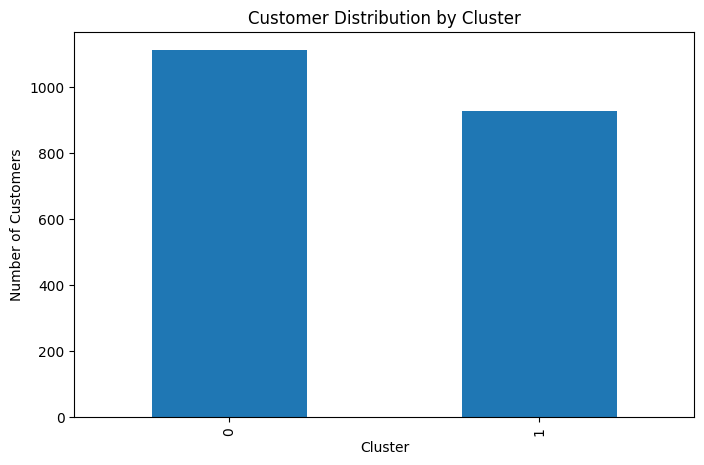

In [49]:
import matplotlib.pyplot as plt

cluster_distribution = df_clustered["Cluster"].value_counts().sort_index()

cluster_distribution.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

### Income Comparison Chart

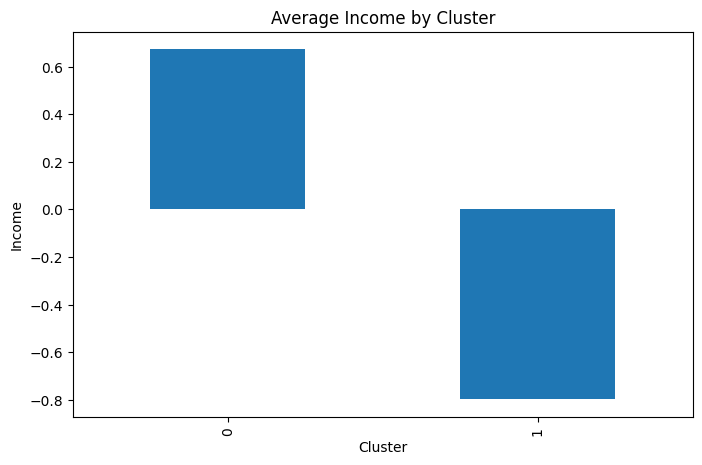

In [51]:
income_chart = df_clustered.groupby("Cluster")["Income"].mean()

income_chart.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Income by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Income")

plt.show()

### Spending Comparison Chart

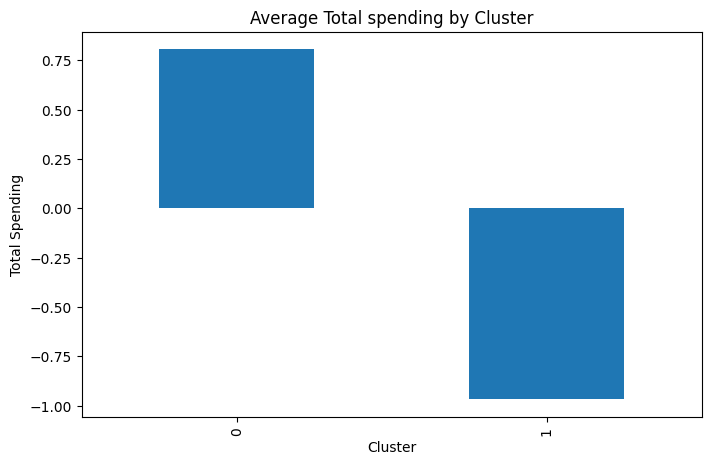

In [54]:
spending_chart = df_clustered.groupby("Cluster")["Total_spending"].mean()

spending_chart.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Total spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Total Spending")

plt.show()

### Product Preference Heatmap

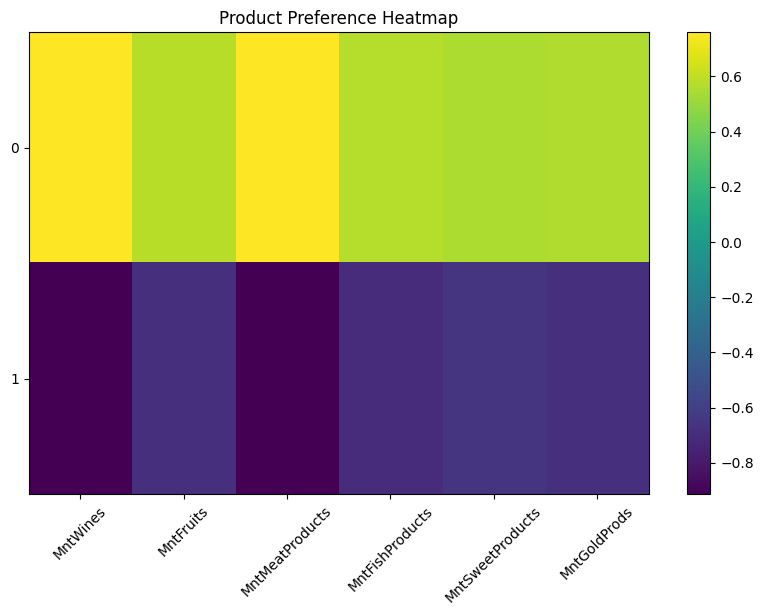

In [55]:
import matplotlib.pyplot as plt

product_heatmap = df_clustered.groupby("Cluster")[[
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]].mean()

plt.figure(figsize=(10,6))

plt.imshow(product_heatmap, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(product_heatmap.columns)),
    product_heatmap.columns,
    rotation=45
)

plt.yticks(
    range(len(product_heatmap.index)),
    product_heatmap.index
)

plt.title("Product Preference Heatmap")

plt.show()

### Purchasing Channel Comparison Chart

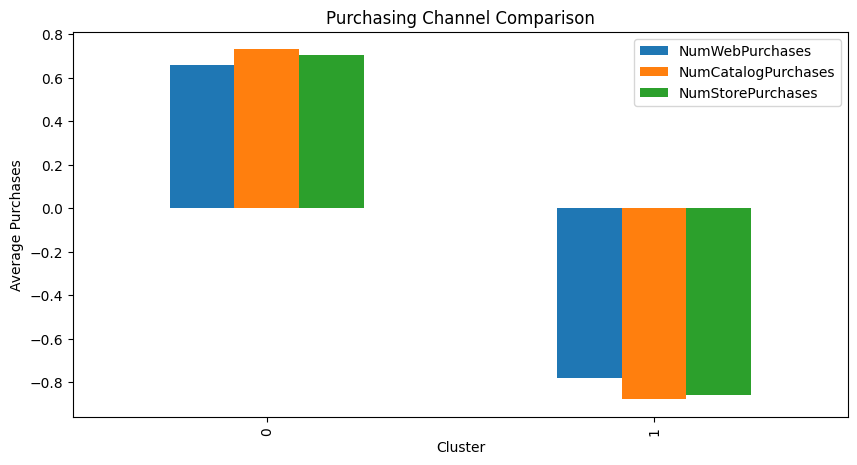

In [56]:
channel_chart = df_clustered.groupby("Cluster")[[
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]].mean()

channel_chart.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Purchasing Channel Comparison")
plt.xlabel("Cluster")
plt.ylabel("Average Purchases")

plt.show()

### Campaign Response Comparison Chart

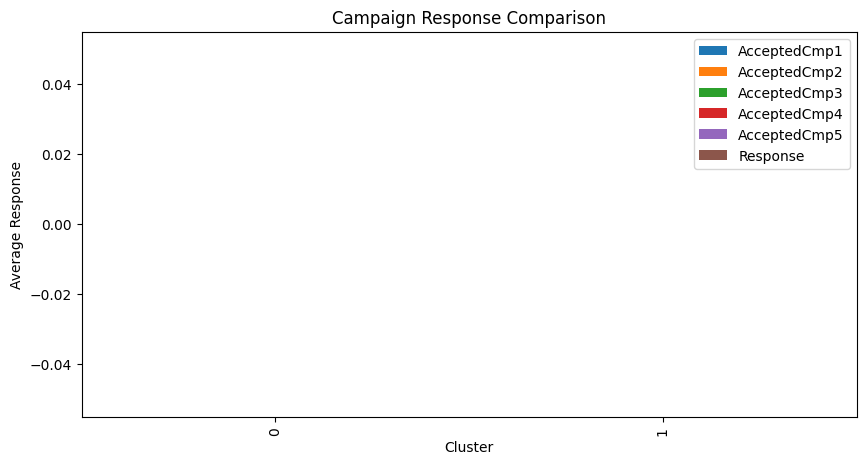

In [57]:
campaign_chart = df_clustered.groupby("Cluster")[[
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]].mean()

campaign_chart.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Campaign Response Comparison")
plt.xlabel("Cluster")
plt.ylabel("Average Response")

plt.show()

### Recency Comparison Chart

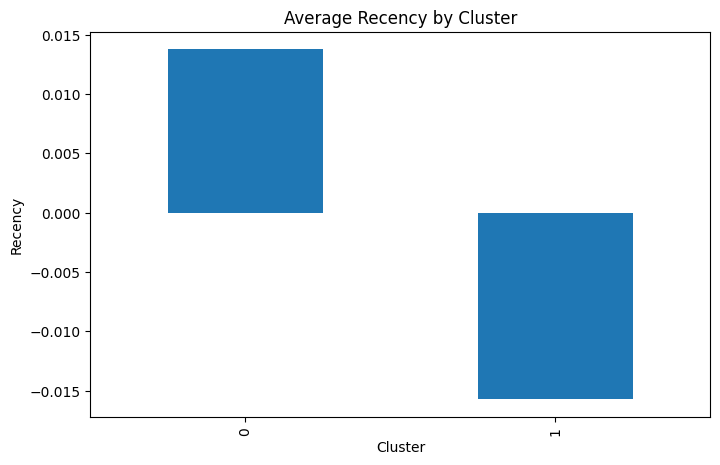

In [58]:
recency_chart = df_clustered.groupby("Cluster")["Recency"].mean()

recency_chart.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Recency by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Recency")

plt.show()

### Radar Chart

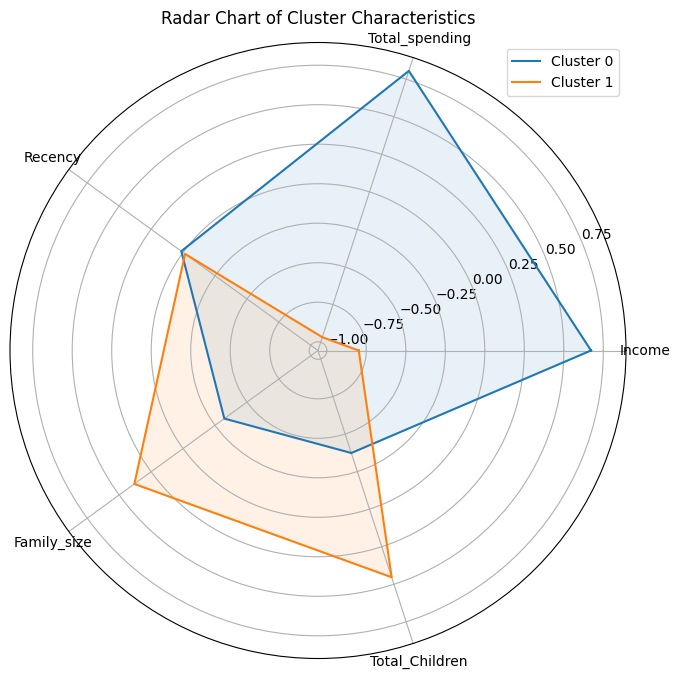

In [62]:
import numpy as np

features = [
    "Income",
    "Total_spending",
    "Recency",
    "Family_size",
    "Total_Children"
]

radar_data = df_clustered.groupby("Cluster")[features].mean()

angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for i in range(len(radar_data)):
    values = radar_data.iloc[i].tolist()
    values += values[:1]

    ax.plot(angles, values, label=f"Cluster {i}")
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)

plt.title("Radar Chart of Cluster Characteristics")
plt.legend()

plt.show()

### Segment Comparison Table

In [65]:
segment_table = df_clustered.groupby("Cluster").agg({

    "Income":"mean",
    "Customer_Age":"mean",
    "Total_spending":"mean",
    "Recency":"mean",
    "Family_size":"mean",
    "NumWebPurchases":"mean",
    "NumStorePurchases":"mean",
    "NumCatalogPurchases":"mean"

}).round(2)

segment_table

,Income,Customer_Age,Total_spending,Recency,Family_size,NumWebPurchases,NumStorePurchases,NumCatalogPurchases
Cluster,,,,,,,,
0,0.67,0.18,0.81,0.01,-0.32,0.66,0.71,0.73
1,-0.80,-0.20,-0.97,-0.02,0.38,-0.78,-0.86,-0.88


### Save Reports

In [67]:
segment_table.to_csv(
    "Segment_Comparison_Table.csv"
)

df_clustered.to_csv(
    "Final_Customer_Profile_Report.csv",
    index=False
)

print("Final reports saved successfully.")

Final reports saved successfully.
